**Bank Data Analysis And Predictions**

##Overview
This projects sets itself to explore banking data concerning possibilities of defaulting using data science tecniques found in Python. The goal is to analyze and customres and visualize key patterns and predictive insights to influence future decision making.

Common tools like numpy, matplotlib, and Pandas to name a few will be used in a Jupyter Notebook.

**Objectives**
1. To visualize the data and unearth any patterns during EDA
2. Clean the data in accordance to te findings of sep 1
3. Develop a machine learning model (logistic regression)
4. Evaluate performance of the said model

In [1]:
#importing the necesssary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression
b_data=pd.read_csv("C:/Users/small/Downloads/Banking_data.csv")#fetching the data set

#view part of the data
b_data.head()
#assigning target and features to y and X respectfully 
X=b_data.drop('Risk_Flag', axis=1)#feature
y=b_data['Risk_Flag']#target

b_data.info()
#print(b_data.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 252000 entries, 0 to 251999
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   Id                 252000 non-null  int64 
 1   Income             252000 non-null  int64 
 2   Age                252000 non-null  int64 
 3   Experience         252000 non-null  int64 
 4   Married/Single     252000 non-null  object
 5   House_Ownership    252000 non-null  object
 6   Car_Ownership      252000 non-null  object
 7   Profession         252000 non-null  object
 8   CITY               252000 non-null  object
 9   STATE              252000 non-null  object
 10  CURRENT_JOB_YRS    252000 non-null  int64 
 11  CURRENT_HOUSE_YRS  252000 non-null  int64 
 12  Risk_Flag          252000 non-null  int64 
dtypes: int64(7), object(6)
memory usage: 25.0+ MB


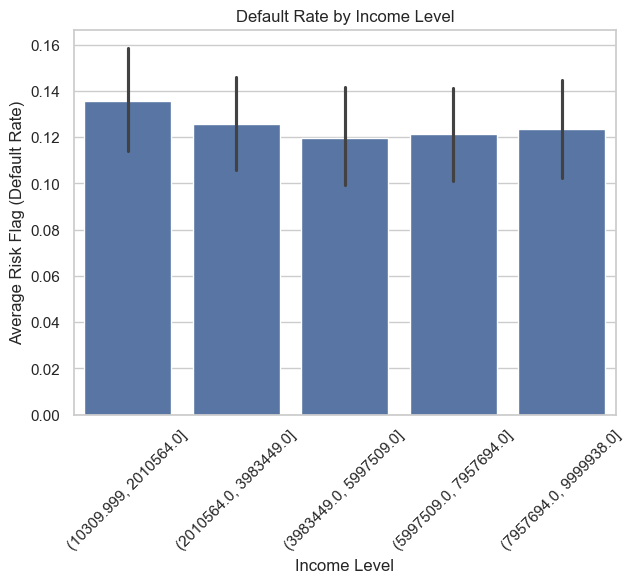

In [2]:
#Visualisation willl begin with income. Displaying a borrowers capacity to pay back or manage debt.
# Create income bands
b_data['Income_Bin'] = pd.qcut(b_data['Income'], q=5)
#control the amount of rows used during plotting to save RAM
b_sample=b_data.sample(n=5000, random_state=42)

# Convert numeric columns to float32 to save memory
numerical_cols = ['Income','Age','Experience','CURRENT_JOB_YRS','CURRENT_HOUSE_YRS']
b_data[numerical_cols] = b_data[numerical_cols].astype('float32')
b_sample[numerical_cols] = b_sample[numerical_cols].astype('float32')

sns.set(style="whitegrid")

'''To prevent having a bar per income which is continuos, Income will be separated into different levels 
creating a new column called Income_Bin'''
plt.figure(figsize=(7,5))
sns.barplot(x='Income_Bin', y='Risk_Flag', data=b_sample)
plt.title('Default Rate by Income Level')
plt.xlabel('Income Level')
plt.ylabel('Average Risk Flag (Default Rate)')
plt.xticks(rotation=45)
plt.show()

C:\Users\small\AppData\Local\Temp\ipykernel_11428\214640449.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pd.cut(b_sample['Age'], bins=8), y='Risk_Flag', data=b_sample, palette='coolwarm')


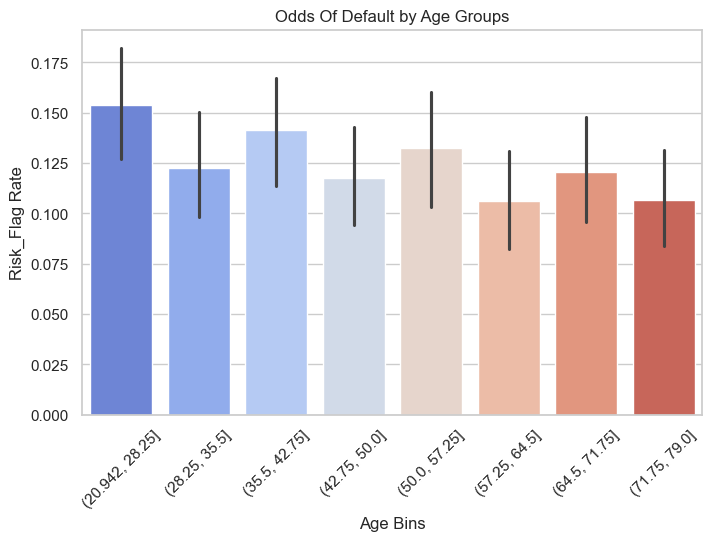

In [5]:
'''Age vs Risk Flag
Age communicates factors as security in life which diectly impacts one's ability to pay back debt, 
but not ignoring the direct correlation between probability of dying before finishing payment in older people. 
A hypothesis that MIDDLE AGED PEOPLE ARE PROBABLY THE LEAST TO DEFAULT IS FORMED.'''

plt.figure(figsize=(8,5))
sns.barplot(x=pd.cut(b_sample['Age'], bins=8), y='Risk_Flag', data=b_sample, palette='coolwarm')
plt.xticks(rotation=45)
plt.title('Odds Of Default by Age Groups')
plt.ylabel('Risk_Flag Rate')
plt.xlabel('Age Bins')
plt.show()

C:\Users\small\AppData\Local\Temp\ipykernel_11428\1309928100.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Risk_Flag', y='Experience', data=b_sample, palette='Set2')


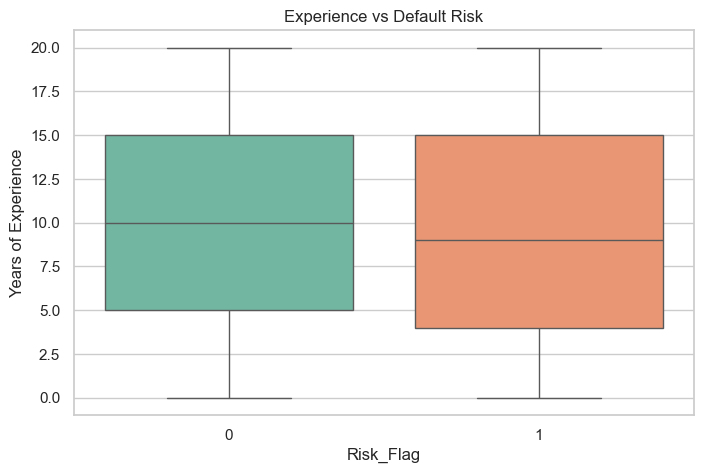

In [4]:
#b_sample is used for pairplots, kde, or scatterplots to save memory
#WHEN SAYING EXPERIENCE IN WHAT WAY ARE WE TALKING ABOUT IT AND HOW DOESIT AFFECT THE TARGET
#THe hypothesis here is that borrowers with more work experience are lesss likely to default
plt.figure(figsize=(8,5))
sns.boxplot(x='Risk_Flag', y='Experience', data=b_sample, palette='Set2')
plt.title('Experience vs Default Risk')
plt.xlabel('Risk_Flag')
plt.ylabel('Years of Experience')
plt.show()

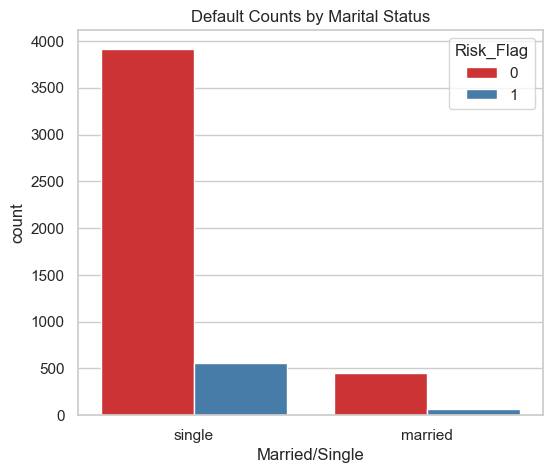

In [27]:
#THE HYPOTHESIS HERE IS THAT MARRIED CUSTOMERS HAVE A LOWER CHANCE OF DEFAULTING UNLIKE THE SINGLES DUE TO FACTORS LIKE SHARED RESPONSIBILITY
#THE MARRIED HOMES ARE PROBABLY LESS LIKELY TO BORROW LOANS TOO DUE TO SHARED BILLS OR COSTS
plt.figure(figsize=(6,5))
sns.countplot(x='Married/Single', hue='Risk_Flag', data=b_sample, palette='Set1')
plt.title('Default Counts by Marital Status')
plt.show()

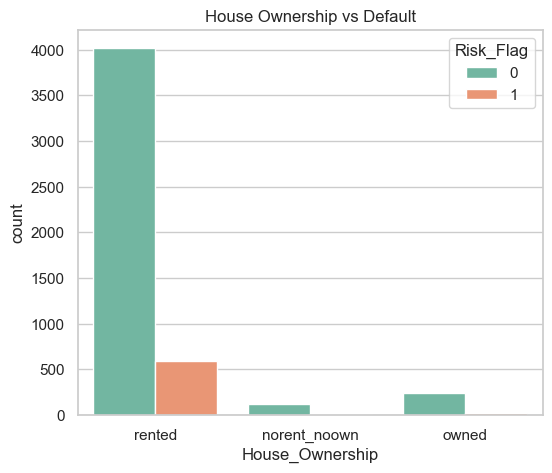

In [28]:
'''just as the other features also communicates stability or security in ones life 
so lower odds of defaulting'''

plt.figure(figsize=(6,5))
sns.countplot(x='House_Ownership', hue='Risk_Flag', data=b_sample, palette='Set2')
plt.title('House Ownership vs Default')
plt.show()

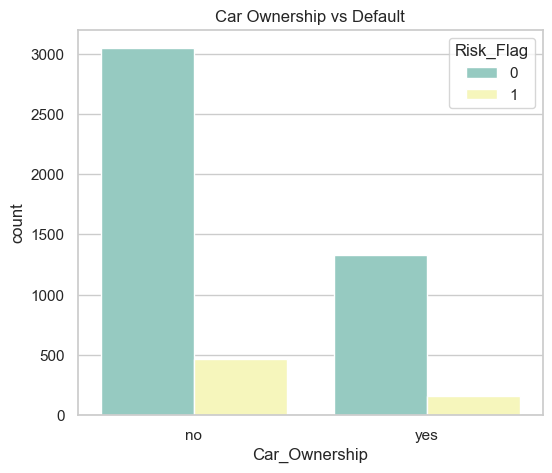

In [29]:
'''car ownership reflects stability or how long someone has had in work (experience) 
which hypothetical means lower odds of defaulting'''

plt.figure(figsize=(6,5))
sns.countplot(x='Car_Ownership', hue='Risk_Flag', data=b_sample, palette='Set3')
plt.title('Car Ownership vs Default')
plt.show()

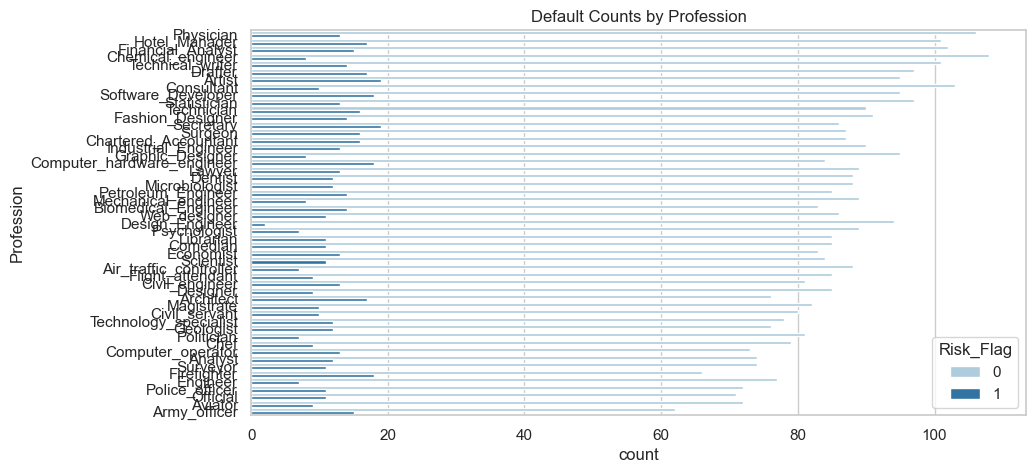

In [6]:
#jobs communicate ones financial income hence the rate at which the loan wil be paid back 
#so a conclusion can be made that it equates to lower odds of defaulting
#but its also worth considering that a certain profession having more defaulters can be because 
#they are the highest number of customers not tHat the profession as many defaulters
plt.figure(figsize=(10,5))
sns.countplot(y='Profession', hue='Risk_Flag', data=b_sample, palette='Paired', order=b_sample['Profession'].value_counts().index)
plt.title('Default Counts by Profession')
plt.show()

**RISK_FLAG VS PROFESSION**
the chart above shows a lot of congestion and and doesn't really communicate the rate of 
defaulting each profession because of the imbalance that may be caused by imbalance in professions so make it hard to use.

C:\Users\small\AppData\Local\Temp\ipykernel_11428\1330544027.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Risk_Flag', y='CURRENT_JOB_YRS', data=b_sample, palette='coolwarm')


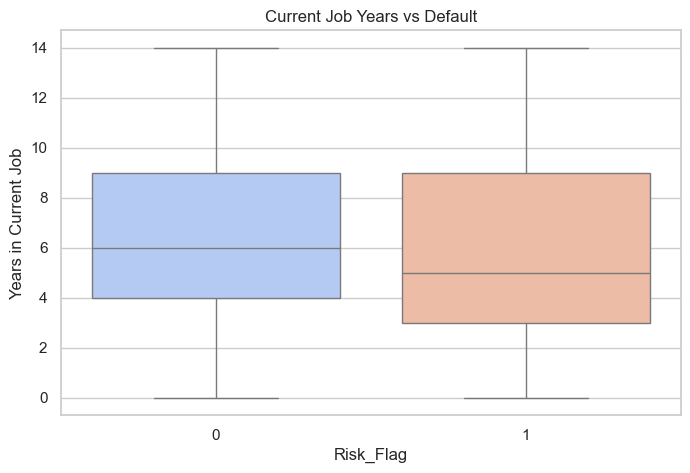

In [7]:
#Customers who have stayed longer in their current job are less likely to default(HYPOTHETICALLY).

plt.figure(figsize=(8,5))
sns.boxplot(x='Risk_Flag', y='CURRENT_JOB_YRS', data=b_sample, palette='coolwarm')
plt.title('Current Job Years vs Default')
plt.xlabel('Risk_Flag')
plt.ylabel('Years in Current Job')
plt.show()

The graph above tells us a few things like approximates of defaulters, 
the years they had their jobs in medians (median for defaulters approximately 5 years and non defaulters being around 6 years. Defaulters show slightly more concentration at lower job years.

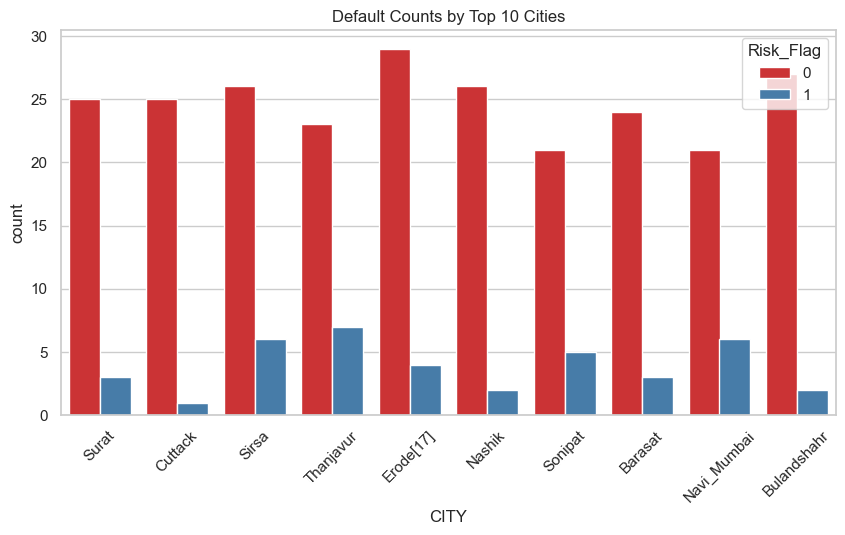

In [10]:
# For large categorical features, top 10 most common were used for 
#plotting or studying relation with the default rate or count per city
top_cities = b_sample['CITY'].value_counts().nlargest(10).index
plt.figure(figsize=(10,5))
sns.countplot(x='CITY', hue='Risk_Flag', data=b_sample[b_sample['CITY'].isin(top_cities)], palette='Set1')
plt.title('Default Counts by Top 10 Cities')
plt.xticks(rotation=45)
plt.show()

**Data Cleaning and Preprocessing**

Data cleaning was performed to ensure the dataset was logically consistent, analytically meaningful, and suitable for exploratory data analysis. Given the large size of the dataset, particular attention was paid to inconsistencies, rare categories, and variables with OvERLY granular values that could distort analysis or visualizations.

1. Logical Consistency Checks

Certain variables were examined for logical CONSISTENCY. Specifically, experience-related attributes were reviewed to ensure realistic relationships between them. For example, employment-related features were checked to avoid contradictions such as cases where experience exceeds years spent in the current job, which would be logically inconsistent. Records violating such rules were identified and removed to maintain data integrity (assuming they are a small percentage of the entire datset).

2. Handling Rare Categories

Several categorical variables, particularly City and Profession, contained many categories with very few observations. These rare categories can introduce noise, reduce interpretability, and negatively affect visualizations and downstream analysis. To address this, infrequently occurring categories were grouped into a new category labeled “Other”. This approach preserves overall information while improving clarity and analytical robustness.

3. Binning Continuous Variables

Some continuous variables, such as Income, contained a large number of unique values. While this level of granularity is useful in raw form, it complicates analysis and visualization as seen already. To improve interpretability, income values were grouped into discrete income bands or levels. This transformation allowed for clearer comparison of default risk across income levels and supports meaningful pattern discovery.

4. Dataset Reduction for Efficiency

Given the large size of the dataset, records that violated logical rules or added minimal analytical value were removed. This reduction improves computational efficiency while retaining the core structure and trends necessary for reliable exploratory analysis.

In [14]:
#rare categories
count_min=100#this is what tells us if a city is appearing frequent enough
city_counts = b_data['CITY'].value_counts()#count the number of times a city appears in a data set
rare_cities = city_counts[city_counts<count_min].index#creating a series and a boolean  (True=rare city and False=common city)
b_data['CITY_CLEAN'] = b_data['CITY'].replace(rare_cities, 'Other')

In [15]:
#same tings done to city above were done here but to Profession
profession_counts = b_data['Profession'].value_counts()
rare_professions = profession_counts[profession_counts<count_min ].index

b_data['Profession_CLEAN'] = b_data['Profession'].replace(rare_professions, 'Other')

In [16]:
#drop certain columns that are now not in use
b_data.drop(columns=['CITY', 'Profession', 'Id'], inplace=True)

In [17]:
b_data.info()
b_data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 252000 entries, 0 to 251999
Data columns (total 14 columns):
 #   Column             Non-Null Count   Dtype   
---  ------             --------------   -----   
 0   Id                 252000 non-null  int64   
 1   Income             252000 non-null  float32 
 2   Age                252000 non-null  float32 
 3   Experience         252000 non-null  float32 
 4   Married/Single     252000 non-null  object  
 5   House_Ownership    252000 non-null  object  
 6   Car_Ownership      252000 non-null  object  
 7   STATE              252000 non-null  object  
 8   CURRENT_JOB_YRS    252000 non-null  float32 
 9   CURRENT_HOUSE_YRS  252000 non-null  float32 
 10  Risk_Flag          252000 non-null  int64   
 11  Income_Bin         252000 non-null  category
 12  CITY_CLEAN         252000 non-null  object  
 13  Profession_CLEAN   252000 non-null  object  
dtypes: category(1), float32(5), int64(2), object(6)
memory usage: 20.4+ MB


,Id,Income,Age,Experience,Married/Single,House_Ownership,Car_Ownership,STATE,CURRENT_JOB_YRS,CURRENT_HOUSE_YRS,Risk_Flag,Income_Bin,CITY_CLEAN,Profession_CLEAN
0,1,1303834.0,23.0,3.0,single,rented,no,Madhya_Pradesh,3.0,13.0,0,"(10309.999, 2010564.0]",Rewa,Mechanical_engineer
1,2,7574516.0,40.0,10.0,single,rented,no,Maharashtra,9.0,13.0,0,"(5997509.0, 7957694.0]",Parbhani,Software_Developer
2,3,3991815.0,66.0,4.0,married,rented,no,Kerala,4.0,10.0,0,"(3983449.0, 5997509.0]",Alappuzha,Technical_writer
3,4,6256451.0,41.0,2.0,single,rented,yes,Odisha,2.0,12.0,1,"(5997509.0, 7957694.0]",Bhubaneswar,Software_Developer
4,5,5768871.0,47.0,11.0,single,rented,no,Tamil_Nadu,3.0,14.0,1,"(3983449.0, 5997509.0]",Tiruchirappalli[10],Civil_servant


In [21]:
#logical inconsistencies
exp_col = 'Experience'
job_col = 'CURRENT_JOB_YRS'
house_col = 'CURRENT_HOUSE_YRS'

#there are certain rules to follow to confirm these inconcistencies, like Experience ≤ Age, 
#CURRENT_JOB_YRS ≤ Experience, CURRENT_HOUSE_YRS ≤ Age, and lasly, any negative time vairables.
age_col = 'Age'
exp_age_violation = b_data[b_data[exp_col] > b_data[age_col]]
len(exp_age_violation)
job_exp_violation = b_data[b_data[job_col] > b_data[exp_col]]
len(job_exp_violation)
house_age_violation = b_data[b_data[house_col] > b_data[age_col]]
len(house_age_violation) 

0

**Logical Inconsistencies**

Inconsistencies in the dataset were screeened for to check the credibility of the relationships between age, experience, employment duration, adn housing tenure using the code and rules above.
Te code output 0 which communicates that te set is 100% plausible and so no need for cleaning.

<Axes: xlabel='Risk_Flag'>

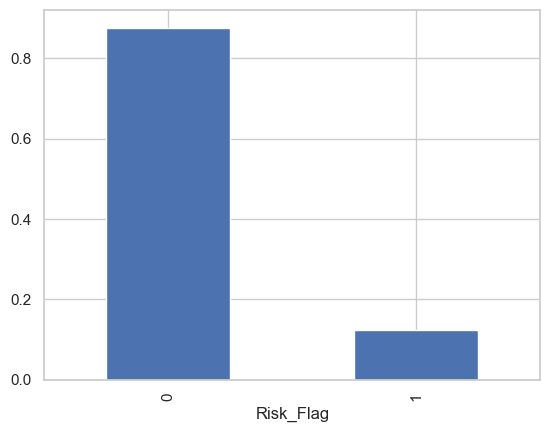

In [24]:
#IMBLANCE OF THE DATA SET ANSWERING THE QUESTON WICH IS MORE, DEFAULTS OR  
b_data['Risk_Flag'].value_counts(normalize=True)
b_data['Risk_Flag'].value_counts(normalize=True).plot(kind='bar')

##Logistic regression is a model that works on numerical data and so assumes each cokumn is numeric,  and each value in there has a meaning tied to its quantity. Seeing as how this data set is imbalanced and has some of the low cardinality columns which are also useful in predicting the chance of flagging,it leads to te next step. Encoding and fit transforming.

In [ ]:
#ENCODE CATEGORICAL  AND TRANSFORM OF NUMERICAL COLUMNS
#BUT FIRST CHANGE DATA TYPES FROM OBJECT TO CATERGORICAL AND THHE DROP ANY HIGH CARDINALITY COLUMNS 
# Convert categorical columns to category
categorical_cols = ['Married/Single','House_Ownership','Car_Ownership','STATE','CITY_CLEAN','Profession_CLEAN','Income_Bin']

#CHANGE DATA TYPES FROM OBJECTS WHERE PYTHON WILL TAKE THEM AS str to categorical for encoding
for col in categorical_cols:
    b_data[col] = b_data[col].astype('category')

# Drop high-cardinality / unnecessary columns
b_data = b_data.drop(columns=['CITY_CLEAN', 'Profession_CLEAN', 'Income_Bin'])

Some data columns have very high values compared to others,for exmple income compared to age. To ensure each column as a fair contribution to te outcome we get the next step.

In [26]:
#fit transform numerical data 
from sklearn.preprocessing import StandardScaler

num_cols = ['Income', 'Age', 'Experience', 'CURRENT_JOB_YRS', 'CURRENT_HOUSE_YRS']
scaler = StandardScaler()
b_data[num_cols] = scaler.fit_transform(b_data[num_cols])

# Update features and target
X = b_data.drop(columns=['Id', 'Risk_Flag'])
y = b_data['Risk_Flag']

In [27]:
# One-Hot Encode remaining categorical columns
X = pd.get_dummies(X, drop_first=True)

In [ ]:
MODEL PREPARATION
STARTS WITH SPLITTING THE DATA SET INTO TRAIN AND TEST DATA SETS

In [28]:
# Split into training and testing sets (stratified)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [30]:
# Train Logistic Regression model
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

model = LogisticRegression(max_iter=1000,  random_state=42, class_weight='balanced' )#handles class imbalance

model.fit(X_train, y_train)#fitting the model

# Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# Evaluation of the model
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.54      0.67     66301
           1       0.14      0.56      0.23      9299

    accuracy                           0.54     75600
   macro avg       0.52      0.55      0.45     75600
weighted avg       0.80      0.54      0.62     75600

